# Figure 5C Supplement: CFU at Timepoint 0
This notebook plots **CFU at timepoint = 0** 
1. **S. aureus CFU0** in presence of different *P. aeruginosa* partners
2. ***P. aeruginosa* CFU0** (different *P. aeruginosa* targets in co-culture with *S. aureus*)

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker

# =============================================================================
# CONFIGURATION
# =============================================================================
matplotlib.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.width': 0.5,
    'ytick.major.size': 2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

checker_order = ['mixed', 'small', 'medium', 'big']
groups_to_plot = ['wt', 'RHL+', 'HQNO+']

color_map = {
    'wt': '#ffcc66',
    'RHL+': '#cc99ff',
    'HQNO+': '#669966',
}

name_map = {
    'P. aeruginosa wt': 'wt',
    'P. aeruginosa ∆∆rhlApqsL': '∆∆',
    'P. aeruginosa pqsL+': 'HQNO+',
    'P. aeruginosa rhlAB+': 'RHL+',
}

# =============================================================================
# LOAD DATA
# =============================================================================
file_names = ['20251030.csv', '20251105.csv', '20251114.csv']
data_dir = os.path.join('..', 'Figure5', '5BC')
all_data = []

for i, fname in enumerate(file_names, start=1):
    csv_path = os.path.join(data_dir, fname)
    df = pd.read_csv(csv_path)
    df['replicate'] = i
    all_data.append(df)
    print(f'Loaded replicate {i}: {csv_path}')

raw_df = pd.concat(all_data, ignore_index=True)
raw_df['cfu'] = pd.to_numeric(raw_df['cfu'], errors='coerce')

# Keep only timepoint 0 and rows with valid CFU
df0 = raw_df[(raw_df['timepoint'] == 0) & raw_df['cfu'].notna()].copy()

# Panel 1: S. aureus CFU0 in presence of PA partners
sa_df = df0[df0['target'] == 'S. aureus'].copy()
sa_df['partner_label'] = sa_df['partner'].map(name_map)
sa_df = sa_df[sa_df['partner_label'].isin(groups_to_plot)].copy()

# Panel 2: P. aeruginosa CFU0 (PA targets) in co-culture with S. aureus
pa_df = df0[
    (df0['target'].str.startswith('P. aeruginosa', na=False))
    & (df0['partner'] == 'S. aureus')
].copy()
pa_df['pa_label'] = pa_df['target'].map(name_map)
pa_df = pa_df[pa_df['pa_label'].isin(groups_to_plot)].copy()

print(f'\nS. aureus rows at t0: {len(sa_df)}')
print(f'P. aeruginosa rows at t0: {len(pa_df)}')

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def _group_stats(df, group_col):
    """Compute mean and SD per checkerboard and group."""
    stats_rows = []
    for chk in checker_order:
        for grp in groups_to_plot:
            vals = df[(df['checkerboard'] == chk) & (df[group_col] == grp)]['cfu'].dropna().to_numpy(dtype=float)
            n = len(vals)

            if n == 0:
                mean_val = np.nan
                sd_val = np.nan
            elif n == 1:
                mean_val = float(vals[0])
                sd_val = 0.0
            else:
                mean_val = float(np.mean(vals))
                sd_val = float(np.std(vals, ddof=1))

            stats_rows.append({
                'checkerboard': chk,
                'group': grp,
                'mean': mean_val,
                'sd': sd_val,
                'n': n,
            })

    out = pd.DataFrame(stats_rows)
    out['checkerboard'] = pd.Categorical(out['checkerboard'], categories=checker_order, ordered=True)
    out['group'] = pd.Categorical(out['group'], categories=groups_to_plot, ordered=True)
    return out.sort_values(['checkerboard', 'group'])

# =============================================================================
# PLOT HELPERS
# =============================================================================
def plot_grouped_cfu_bar(ax, df, group_col, title, y_max_k):
    """Create grouped barplot with error bars, replicate dots, and 1e3 scaling."""
    stats_df = _group_stats(df, group_col)

    x = np.arange(len(checker_order))
    width = 0.24

    for i, grp in enumerate(groups_to_plot):
        st = stats_df[stats_df['group'] == grp].set_index('checkerboard').reindex(checker_order)

        means = st['mean'].to_numpy(dtype=float)
        sds = st['sd'].to_numpy(dtype=float)

        x_pos = x + (i - (len(groups_to_plot) - 1) / 2.0) * width

        ax.bar(
            x_pos,
            means,
            width=width,
            color=color_map[grp],
            edgecolor='black',
            linewidth=0.5,
            label=grp,
            alpha=0.85,
            zorder=2,
        )

        ax.errorbar(
            x_pos,
            means,
            yerr=sds,
            fmt='none',
            ecolor='black',
            elinewidth=0.5,
            capsize=3,
            capthick=0.5,
            zorder=3,
        )

        for j, chk in enumerate(checker_order):
            subset = df[(df['checkerboard'] == chk) & (df[group_col] == grp)]
            if len(subset) > 0:
                x_jitter = np.random.normal(0, 0.03, size=len(subset))
                x_positions = np.full(len(subset), x_pos[j]) + x_jitter
                ax.scatter(
                    x_positions,
                    subset['cfu'].values,
                    s=20,
                    color='black',
                    alpha=0.5,
                    zorder=4,
                    edgecolor='none',
                )

    ax.set_xlabel('Segregation pattern', fontsize=8)
    ax.set_ylabel('CFU at t = 0', fontsize=8)
    ax.set_title(title, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in checker_order], fontsize=8)

    # Linear axis with 1e3 indicator and 4 equal intervals from 0 to max.
    y_max = y_max_k * 1e3
    ax.set_ylim(0, y_max)
    y_tick_k = np.linspace(0, y_max_k, 5)
    y_ticks = y_tick_k * 1e3
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{v:g}' for v in y_tick_k])
    ax.text(0.0, 1.01, '1e3', transform=ax.transAxes, ha='left', va='bottom', fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.grid(False)

Loaded replicate 1: ../Figure5/5BC/20251030.csv
Loaded replicate 2: ../Figure5/5BC/20251105.csv
Loaded replicate 3: ../Figure5/5BC/20251114.csv

S. aureus rows at t0: 36
P. aeruginosa rows at t0: 36


## Figure 5C Supplement: CFU0 Across Segregation Patterns

Two-panel barplot of CFU at **timepoint = 0** with replicate dots and SD error bars:
- Left panel: *S. aureus* CFU0 in presence of different *P. aeruginosa* partners
- Right panel: *P. aeruginosa* CFU0 across partner strains in co-culture with *S. aureus*

Y-axis is displayed with a `1e3` multiplier and panel-specific ranges.

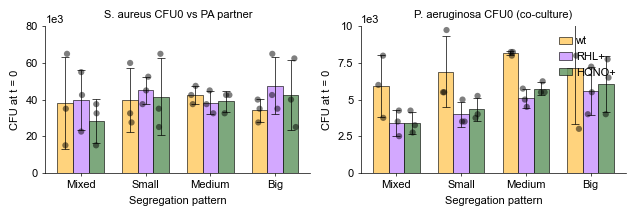

Saved: S17_CFU0.pdf


In [2]:
# =============================================================================
# PLOT
# =============================================================================
fig, axs = plt.subplots(1, 2, figsize=(6.4, 2.2))

plot_grouped_cfu_bar(
    axs[0],
    sa_df,
    group_col='partner_label',
    title='S. aureus CFU0 vs PA partner',
    y_max_k=80,
)

plot_grouped_cfu_bar(
    axs[1],
    pa_df,
    group_col='pa_label',
    title='P. aeruginosa CFU0 (co-culture)',
    y_max_k=10,
)

axs[1].legend(
    frameon=False,
    fontsize=8,
    loc='upper right',
    handlelength=1.2,
    handletextpad=0.4,
)

plt.tight_layout()
plt.savefig('S17_CFU0.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: S17_CFU0.pdf')

## Statistical Analysis: Kruskal-Wallis Tests

Non-parametric comparisons across the three partner groups:
- Test 1: *S. aureus* CFU0 across PA partner strains
- Test 2: *P. aeruginosa* CFU0 across PA strains

Each test reports group sizes, Kruskal-Wallis H statistic, p-value, interpretation, and descriptive statistics.

In [3]:
# =============================================================================
# STATISTICAL ANALYSIS: KRUSKAL-WALLIS (WITHIN CHECKERBOARD)
# =============================================================================
from scipy import stats


def run_kw_within_checkerboard(df, group_col, panel_label):
    """Run Kruskal-Wallis across strains within each checkerboard."""
    print("\n" + "=" * 80)
    print(f"{panel_label}: KRUSKAL-WALLIS WITHIN EACH CHECKERBOARD")
    print("=" * 80)

    results = []

    for chk in checker_order:
        print("\n" + "-" * 80)
        print(f"Checkerboard: {chk}")
        print("-" * 80)

        groups = [
            df[(df['checkerboard'] == chk) & (df[group_col] == grp)]['cfu'].dropna().values
            for grp in groups_to_plot
        ]
        ns = [len(g) for g in groups]

        print(f"Groups: {groups_to_plot}")
        print(f"Sample sizes: {ns}")

        if sum(n > 0 for n in ns) < 2:
            print("Result: Skipped (fewer than 2 non-empty groups).")
            results.append({
                'panel': panel_label,
                'checkerboard': chk,
                'h_stat': np.nan,
                'p_value': np.nan,
                'p_bonf': np.nan,
                'significance': 'n/a',
            })
            continue

        # Kruskal-Wallis across strains within this checkerboard
        h_stat, p_val = stats.kruskal(*groups)

        print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
        print(f"p-value: {p_val:.6f}")

        if p_val < 0.05:
            print("Result: Significant difference across strains (p < 0.05)")
        else:
            print("Result: No significant difference across strains (p >= 0.05)")

        print("Descriptive statistics:")
        for grp in groups_to_plot:
            vals = df[(df['checkerboard'] == chk) & (df[group_col] == grp)]['cfu'].dropna().values
            if len(vals) == 0:
                print(f"  {grp:6s}: n=0")
            elif len(vals) == 1:
                print(f"  {grp:6s}: n=1, median={np.median(vals):.1f}, mean={np.mean(vals):.1f}, SD=0.0")
            else:
                print(
                    f"  {grp:6s}: n={len(vals):2d}, "
                    f"median={np.median(vals):.1f}, mean={np.mean(vals):.1f}, SD={np.std(vals, ddof=1):.1f}"
                )

        results.append({
            'panel': panel_label,
            'checkerboard': chk,
            'h_stat': h_stat,
            'p_value': p_val,
        })

    results_df = pd.DataFrame(results)

    # Bonferroni correction across checkerboards within this panel
    valid_mask = results_df['p_value'].notna()
    n_tests = int(valid_mask.sum())
    results_df['p_bonf'] = np.nan
    if n_tests > 0:
        results_df.loc[valid_mask, 'p_bonf'] = np.minimum(results_df.loc[valid_mask, 'p_value'] * n_tests, 1.0)

    def _sig(p):
        if pd.isna(p):
            return 'n/a'
        if p < 0.001:
            return '***'
        if p < 0.01:
            return '**'
        if p < 0.05:
            return '*'
        return 'ns'

    results_df['significance'] = results_df['p_bonf'].apply(_sig)

    print("\n" + "=" * 80)
    print(f"SUMMARY ({panel_label})")
    print("Bonferroni correction across checkerboards within this panel")
    print("=" * 80)
    print(results_df.to_string(index=False))

    return results_df


# Test 1: S. aureus CFU0 across PA partners, within each checkerboard
kw_sa = run_kw_within_checkerboard(
    sa_df,
    group_col='partner_label',
    panel_label='S. aureus CFU0 vs PA partners',
)

# Test 2: P. aeruginosa CFU0 across PA strains, within each checkerboard
kw_pa = run_kw_within_checkerboard(
    pa_df,
    group_col='pa_label',
    panel_label='P. aeruginosa CFU0 across PA strains',
)

print("\n" + "=" * 80)
print("END OF STATISTICAL ANALYSIS")
print("=" * 80)


S. aureus CFU0 vs PA partners: KRUSKAL-WALLIS WITHIN EACH CHECKERBOARD

--------------------------------------------------------------------------------
Checkerboard: mixed
--------------------------------------------------------------------------------
Groups: ['wt', 'RHL+', 'HQNO+']
Sample sizes: [3, 3, 3]
Kruskal-Wallis H-statistic: 0.9636
p-value: 0.617675
Result: No significant difference across strains (p >= 0.05)
Descriptive statistics:
  wt    : n= 3, median=35000.0, mean=38333.3, SD=25166.1
  RHL+  : n= 3, median=42500.0, mean=40000.0, SD=16393.6
  HQNO+ : n= 3, median=32500.0, mean=28333.3, SD=11814.5

--------------------------------------------------------------------------------
Checkerboard: small
--------------------------------------------------------------------------------
Groups: ['wt', 'RHL+', 'HQNO+']
Sample sizes: [3, 3, 3]
Kruskal-Wallis H-statistic: 0.6222
p-value: 0.732632
Result: No significant difference across strains (p >= 0.05)
Descriptive statistics:
  w